In [5]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

from gmr import GMM
# add ../ to the path
import sys
sys.path.append('../')

import src.model as model

%load_ext autoreload
%autoreload 2

data_path       = os.getenv('RAW_DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
output_path     = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
# also the mean and std of Ns for standardization of observed data
Ns_mean_filename     = 'trainingAll_Ns_sim_mean_masked.mat'
Ns_std_filename      = 'trainingAll_Ns_sim_std_masked.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
Ns_standardize_epsilon = preprocess_param['Ns_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("Ns_standardize_epsilon:", Ns_standardize_epsilon)


flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)

# load
Eb_standardized_train = np.load(output_path + XY_train_filename)['Eb_train']
Ns_standardized_train = np.load(output_path + XY_train_filename)['Ns_train']
Eb_standardized_valid = np.load(output_path + XY_valid_filename)['Eb_validation']
Ns_standardized_valid = np.load(output_path + XY_valid_filename)['Ns_validation']
Eb_standardized_test  = np.load(output_path + XY_test_filename)['Eb_test']
Ns_standardized_test  = np.load(output_path + XY_test_filename)['Ns_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

# -------------------------------------------------- LOAD OBSERVATION DATA --------------------------------------------------
Y_obs_data   = scipy.io.loadmat(folder + Y_obs_filename)
# standardization data for Ns
Ns_mean_data = scipy.io.loadmat(folder + Ns_mean_filename)
Ns_std_data  = scipy.io.loadmat(folder + Ns_std_filename)
Ns_mean = Ns_mean_data['Ns_mean_masked']
Ns_std = Ns_std_data['Ns_std_masked']  

Y_obs_data     = Y_obs_data['atten_rate_grid']
atten_rate_avg = Y_obs_data['atten_avg'][0][0]

# apply flightline masking to the standardization mean and std
flight_mask = flight_mask_data['mask']
flight_mask_bool = flight_mask.astype(bool)
Ns_mean_masked = Ns_mean.copy()
Ns_mean_masked[~flight_mask_bool] = 0 # set the mean to 0
Ns_std_masked = Ns_std.copy()
Ns_std_masked[~flight_mask_bool] = 1 # set the std to 1

Ns_mean_masked = Ns_mean_masked.flatten()   
Ns_std_masked  = Ns_std_masked.flatten()

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of Ns_standardized_train:', Ns_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)
print('Shape of flight mask:', flight_mask_bool.shape)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Eb_standardize_epsilon: 1287.4819202075
Ns_standardize_epsilon: 0.262291780650704
Shape of Eb_standardized_train: (256, 256, 1, 937)
Shape of Ns_standardized_train: (256, 256, 1, 937)
Shape of domain mask: (256, 256)
Shape of flight mask: (256, 256)


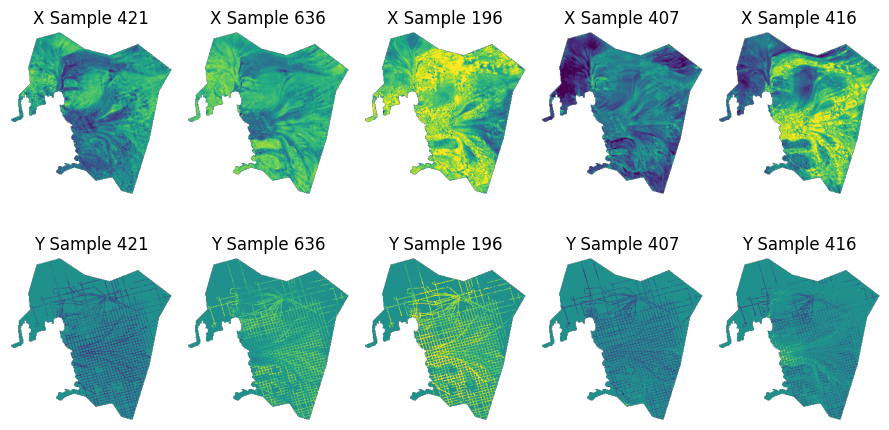

In [6]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
Ns_standardized_all = np.concatenate([Ns_standardized_train, 
                                      Ns_standardized_valid, 
                                      Ns_standardized_test], 
                                      axis=3)
md.load_sim_data(Eb_standardized_all, Ns_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 flight_mask=flight_mask_bool, 
                 show_plot=True)

md.load_standardization_data(X_mean=Eb_mean, X_std=Eb_std,
                             Y_mean=Ns_mean_masked, Y_std=Ns_std_masked,
                             X_epsilon=Eb_standardize_epsilon, Y_epsilon=Ns_standardize_epsilon)

shape of Y_obs: (256, 256)


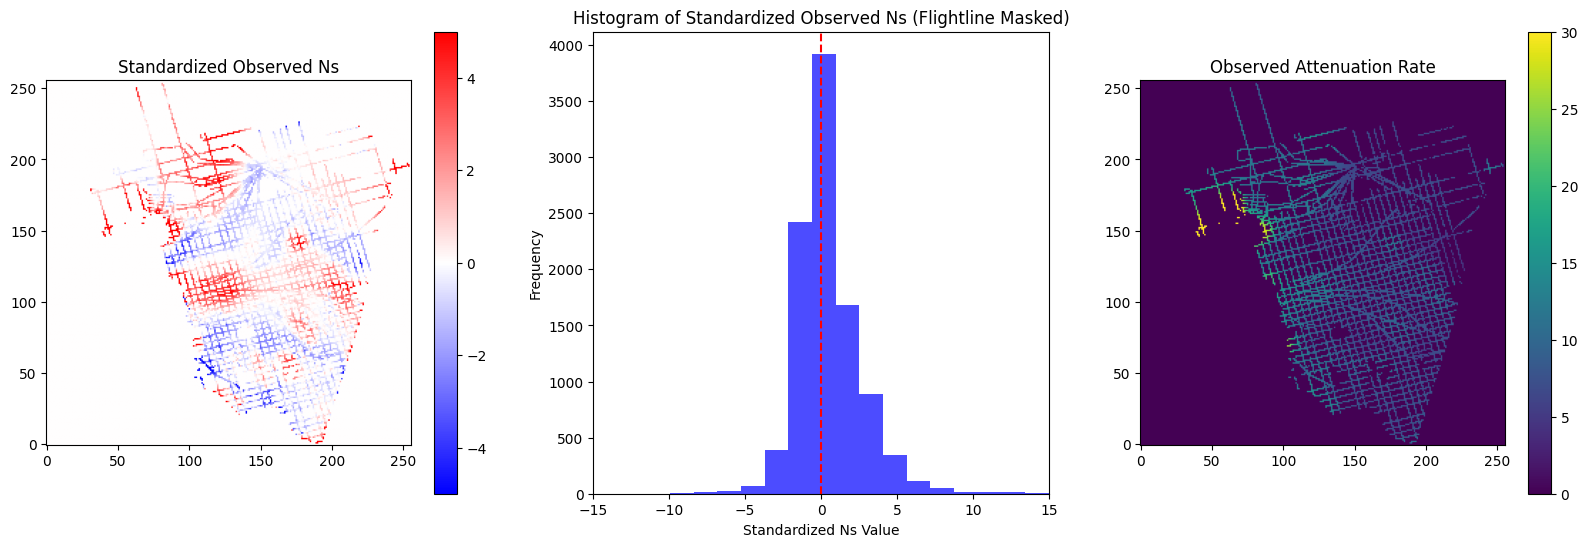

In [8]:
md.load_obs_data(atten_rate_avg)

In [20]:
# reduce dim with PCA. 
md.find_reduction_model_pca(n_component_x=30, n_component_y=10)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PCA
md.load_split_data(X_train=Eb_standardized_train, Y_train=Ns_standardized_train,
                   X_validation=None, Y_validation=None,
                   X_test=Eb_standardized_test, Y_test=Ns_standardized_test)

PCA model saved to self.pca_x and self.pca_y.
Dimension of the fitted dataset for PCA: (1042, 65536) (1042, 65536)
Shape of XY_train: (937, 40)
Shape of XY_validation: None
Shape of XY_test: (105, 40)


In [25]:
# first get a GMM-based prior
gmm_latent = GMM(n_components=3, random_state=np.random.RandomState(42))
gmm_prior = gmm_latent

y_latent_all = md.pca_y.transform(md.Y_ori)

n_latent_samples = y_latent_all.shape[0]
indices = np.arange(n_latent_samples)
local_rng = np.random.RandomState(42) 
local_rng.shuffle(indices)

split_point = int(0.8 * n_latent_samples)
train_indices  = indices[:split_point]
test_indices   = indices[split_point:]
y_latent_train = y_latent_all[train_indices]
y_latent_test  = y_latent_all[test_indices]

# pick a subset for fitting the GMM
first_n = 5
pc_subset = np.linspace(1, first_n, first_n).astype(int) - 1 # pick the first 5 PCs
pc_compli = np.setdiff1d(np.arange(y_latent_all.shape[1]), pc_subset) # the complementary set of PCs
y_latent_train_subset = y_latent_train[:, pc_subset]
truncated_pca_y = md.pca_y.components_[pc_subset,:]

print("Chosen PCs for GMM fitting:", pc_subset)
print("Complementary PCs:", pc_compli)
print("Shape of y_latent_train_subset for GMM fitting:", y_latent_train_subset.shape)
print("Shape of truncated_pca_y:", truncated_pca_y.shape)
# the test set still retains the full latent space

Chosen PCs for GMM fitting: [0 1 2 3 4]
Complementary PCs: [5 6 7 8 9]
Shape of y_latent_train_subset for GMM fitting: (833, 5)
Shape of truncated_pca_y: (5, 65536)


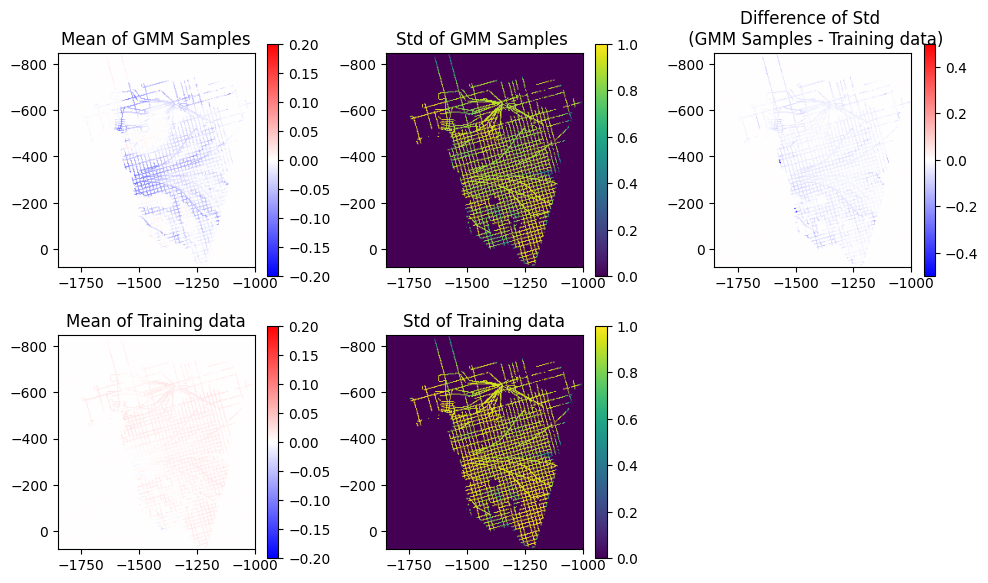

In [26]:
def inverse_transform_truncated(latent_samples, V_truncated):
    # latent_samples: (n_samples, n_truncated_components)
    # V_truncated: (n_truncated_components, n_original_features)
    return latent_samples @ V_truncated


gmm_latent.from_samples(y_latent_train_subset)

# sample from gmm_latent and plot the mean and variance
n_samples = 400
samples_latent = gmm_latent.sample(n_samples)
samples_original = inverse_transform_truncated(samples_latent, truncated_pca_y)
samples_mean = samples_original.mean(axis=0)
samples_std  = samples_original.std(axis=0)

del samples_latent, samples_original

# mean and std of the y_latent_train
y_train = md.Y_ori[train_indices]
y_mean = y_train.mean(axis=0)
y_std  = y_train.std(axis=0)

plt.figure(figsize=(10, 6)) 
plt.subplot(2, 3, 1)
plt.imshow(samples_mean.reshape(md.nx, md.ny), extent=md.extent, origin='lower',
           vmin = -0.2, vmax = 0.2,
           cmap='bwr')
plt.title('Mean of GMM Samples')
plt.colorbar()
plt.subplot(2, 3, 2)
plt.imshow(samples_std.reshape(md.nx, md.ny), extent=md.extent, origin='lower', 
           vmin = 0, vmax = 1)
plt.title('Std of GMM Samples ')
plt.colorbar()
plt.subplot(2, 3, 3)
plt.imshow(samples_std.reshape(md.nx, md.ny) - y_std.reshape(md.nx, md.ny), extent=md.extent, origin='lower',
           vmin = -0.5, vmax = 0.5,
           cmap='bwr')
plt.title('Difference of Std \n (GMM Samples - Training data)')
plt.colorbar()
plt.subplot(2, 3, 4)
plt.imshow(y_mean.reshape(md.nx, md.ny), extent=md.extent, origin='lower', 
           vmin = -0.2, vmax = 0.2,
           cmap='bwr')
plt.title('Mean of Training data')
plt.colorbar()
plt.subplot(2, 3, 5)
plt.imshow(y_std.reshape(md.nx, md.ny), extent=md.extent, origin='lower', 
           vmin = 0, vmax = 1)
plt.title('Std of Training data')
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
from src.utilities import reverse_standardize

obs_uncertainty = 40 # dB/km, this is in the physical space, not standardized space
n_samples       = 200
Na_std          = np.nanmean(md.Y_std) # mean of the standard deviation of the original data

sigma_obs = obs_uncertainty / Na_std # uncertainty in the standardized space
V_trunc = truncated_pca_y.T
V_ori   = md.pca_y.components_.T
V_extra = V_ori[:, pc_compli] # the complementary set of PCs

# iterate over the test set
n_test = y_latent_test.shape[0]

# 5 random samples to save the full data for visualization later
rand_indices = np.random.choice(n_test, size=5, replace=False)
pred_truth_compared = {}

residual_MSE = np.zeros(n_test, dtype=np.float32)
for ii in range(n_test):
    
    obs_latent_full  = y_latent_test[ii,:]
    obs_latent_extra = obs_latent_full[pc_compli] # 
    obs_full  = md.pca_y.inverse_transform(obs_latent_full.reshape(1,-1))
    obs_extra = inverse_transform_truncated(obs_latent_extra, V_extra.T)

    md_posterior = md.compute_posterior(gmm_md=gmm_latent,
                                        A=V_trunc,
                                        obs=obs_full,
                                        sigma_obs_element=sigma_obs**2)

    posterior_samples_latent = md_posterior.sample(n_samples)
    posterior_samples_original = inverse_transform_truncated(posterior_samples_latent, V_trunc.T)

    posterior_mean = posterior_samples_original.mean(axis=0)
    # posterior_std  = posterior_samples_original.std(axis=0)
    # posterior_p01  = np.percentile(posterior_samples_original, 1,  axis=0)
    # posterior_p99  = np.percentile(posterior_samples_original, 99, axis=0)

    posterior_residual = posterior_samples_original - obs_full
    posterior_mean_residual = posterior_mean - obs_full
    # sample dimension is in 0, feature dimension is in 1
    residual_MSE[ii] = np.sqrt(np.mean((posterior_residual-obs_extra)**2, axis=1)).mean() # mean over pixels, then mean over samples

    if ii in rand_indices:
        pred_truth_compared[ii] = (posterior_mean_residual, obs_extra)
        
    if ii % 50 == 0:
        print(f"Processing test sample {ii+1}/{n_test}...")

Processing test sample 1/209...
Processing test sample 51/209...
Processing test sample 101/209...
Processing test sample 151/209...
Processing test sample 201/209...


In [69]:
np.mean((posterior_residual-obs_extra)**2, axis=1).shape

(200,)

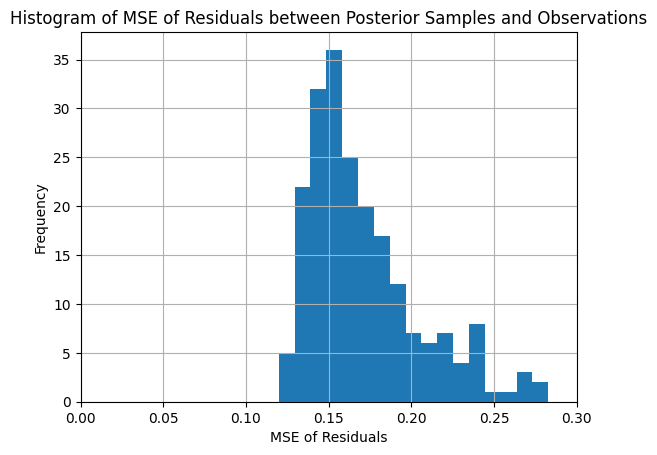

ValueError: cannot reshape array of size 13107200 into shape (256,256)

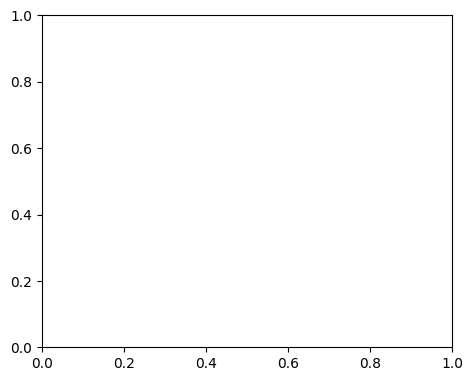

In [55]:
plt.hist(residual_MSE, bins=20)
plt.xlim(0, 0.3)
plt.xlabel('MSE of Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of MSE of Residuals between Posterior Samples and Observations')
plt.grid(True)
plt.show()

# visualize the 5 random samples with full data
plt.figure(figsize=(18,25))

for i, (posterior_residual, obs_extra) in enumerate(pred_truth_compared):
    plt.subplot(5, 3, i*3+1)
    plt.imshow(posterior_residual.reshape(md.nx, md.ny), extent=md.extent, origin='lower', vmin=-0.2, vmax=0.2, cmap='bwr')
    plt.title(f'Posterior Residual (Sample {i+1})')
    plt.colorbar()
    plt.subplot(5, 3, i*3+2)
    plt.imshow(obs_extra.reshape(md.nx, md.ny), extent=md.extent, origin='lower', vmin=-0.2, vmax=0.2, cmap='bwr')
    plt.title(f'Observation Extra (Sample {i+1})')
    plt.colorbar()
    plt.subplot(5, 3, i*3+3)
    plt.imshow((posterior_residual-obs_extra).reshape(md.nx, md.ny), extent=md.extent, origin='lower', vmin=-0.2, vmax=0.2, cmap='bwr')
    plt.title(f'Difference (Posterior Residual - Observation Extra) (Sample {i+1})')
    plt.colorbar()
    plt.tight_layout()
    plt.show()